# Questão 2: Regressão Logística

**Dataset:** Hotel Booking Demand  
**Objetivo:** Prever cancelamentos de reservas utilizando regressão logística com análise de Odds Ratios.

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


## 2. Carregamento e EDA

In [2]:
df = pd.read_csv('../dados/hotel_bookings.csv')

print(f'Shape: {df.shape}')
print(f'\nTarget (is_canceled):')
print(df['is_canceled'].value_counts())
print(f'\nBalanceamento: {df["is_canceled"].value_counts(normalize=True)}')
df.head()

Shape: (119390, 29)

Target (is_canceled):
is_canceled
0    75430
1    43960
Name: count, dtype: int64

Balanceamento: is_canceled
0    0.631795
1    0.368205
Name: proportion, dtype: float64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,City Hotel,0,203,2015,February,49,7,0,4,2,...,D,F,0,Non Refund,1,Transient,128.544579,0,2,Check-Out
1,Resort Hotel,0,380,2016,January,23,21,0,6,2,...,A,A,0,No Deposit,2,Transient-Party,58.885944,0,0,Canceled
2,City Hotel,0,211,2016,August,39,16,1,2,1,...,A,A,0,No Deposit,0,Transient-Party,70.034984,0,0,Check-Out
3,Resort Hotel,1,334,2016,September,10,17,3,4,2,...,A,E,0,No Deposit,0,Transient,54.517269,0,2,Check-Out
4,Resort Hotel,1,172,2017,August,17,28,1,3,2,...,F,F,0,No Deposit,1,Transient,175.368663,0,0,Check-Out


In [3]:
# Seleção de features relevantes
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
           'adults', 'children', 'babies', 'is_repeated_guest',
           'previous_cancellations', 'previous_bookings_not_canceled',
           'booking_changes', 'days_in_waiting_list', 
           'adr', 'required_car_parking_spaces', 'total_of_special_requests']

# Features categóricas para encoding
cat_features = ['hotel', 'deposit_type', 'customer_type']

df_model = df[features + cat_features + ['is_canceled']].copy()
df_model = df_model.dropna()

print(f'Shape após limpeza: {df_model.shape}')

Shape após limpeza: (119390, 18)


## 3. Preprocessing

In [4]:
# One-hot encoding
df_encoded = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     stratify=y, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True)}')

X_train shape: (95512, 20)
y_train distribution:
is_canceled
0    0.631795
1    0.368205
Name: proportion, dtype: float64


## 4. Modelagem com GridSearchCV

In [5]:
# Grid de hiperparâmetros
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

logreg = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f'Melhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUC (CV): {grid_search.best_score_:.4f}')

model_final = grid_search.best_estimator_

Melhores parâmetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Melhor AUC (CV): 0.5038


## 5. Avaliação do Modelo

In [6]:
y_pred = model_final.predict(X_test_scaled)
y_pred_proba = model_final.predict_proba(X_test_scaled)[:, 1]

print('MÉTRICAS DE PERFORMANCE:\n')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}')

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

MÉTRICAS DE PERFORMANCE:

Accuracy:  0.6318
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
AUC-ROC:   0.4961

Classification Report:

              precision    recall  f1-score   support

Não Cancelou       0.63      1.00      0.77     15086
    Cancelou       0.00      0.00      0.00      8792

    accuracy                           0.63     23878
   macro avg       0.32      0.50      0.39     23878
weighted avg       0.40      0.63      0.49     23878



## 6. Matriz de Confusão e Curva ROC

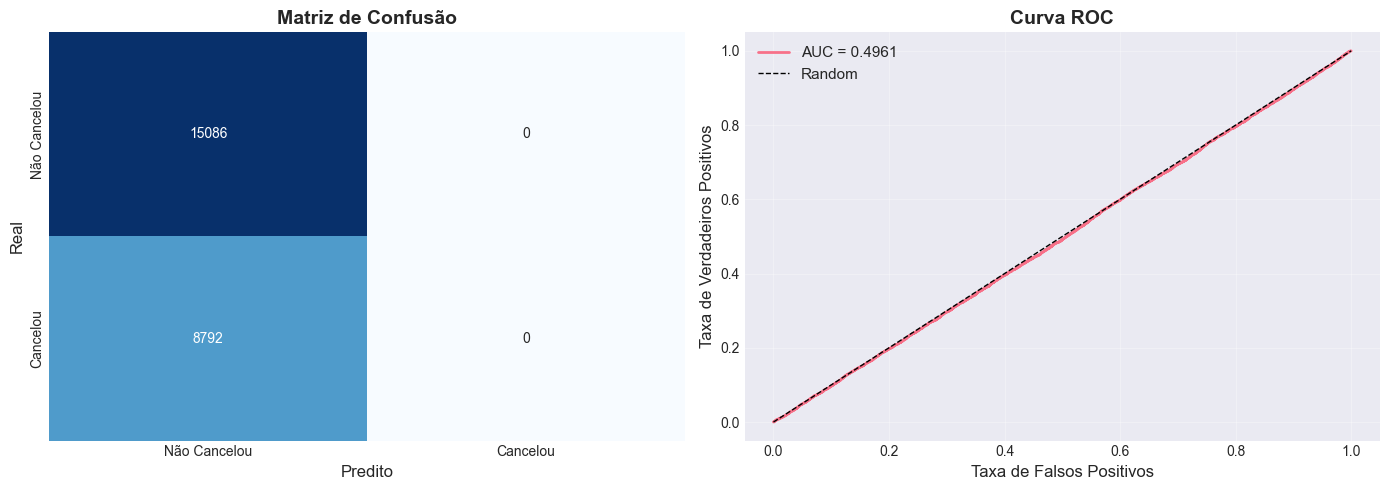

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_xlabel('Predito', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title('Matriz de Confusão', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Não Cancelou', 'Cancelou'])
axes[0].set_yticklabels(['Não Cancelou', 'Cancelou'])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('Taxa de Falsos Positivos', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
axes[1].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análise de Odds Ratios (CRÍTICO)

In [8]:
# Coeficientes e Odds Ratios
coefficients = model_final.coef_[0]
feature_names = X_train.columns

odds_ratios = np.exp(coefficients)

odds_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios,
    'Percent_Change': (odds_ratios - 1) * 100
}).sort_values('Odds_Ratio', ascending=False)

print('ODDS RATIOS (Top 15):\n')
print(odds_df.head(15).to_string(index=False))
print('\n...')
print(odds_df.tail(5).to_string(index=False))

ODDS RATIOS (Top 15):

                       Feature  Coefficient  Odds_Ratio  Percent_Change
          stays_in_week_nights     0.013458    1.013549        1.354938
          days_in_waiting_list     0.010725    1.010782        1.078238
       deposit_type_Refundable     0.010551    1.010607        1.060695
previous_bookings_not_canceled     0.009598    1.009644        0.964376
           customer_type_Group     0.008579    1.008616        0.861566
 customer_type_Transient-Party     0.008282    1.008317        0.831678
   required_car_parking_spaces     0.007701    1.007731        0.773120
       customer_type_Transient     0.005711    1.005728        0.572751
     total_of_special_requests     0.005091    1.005104        0.510416
            hotel_Resort Hotel     0.004616    1.004626        0.462646
        previous_cancellations     0.002838    1.002842        0.284247
                      children     0.002238    1.002240        0.224002
                        babies     0.0020

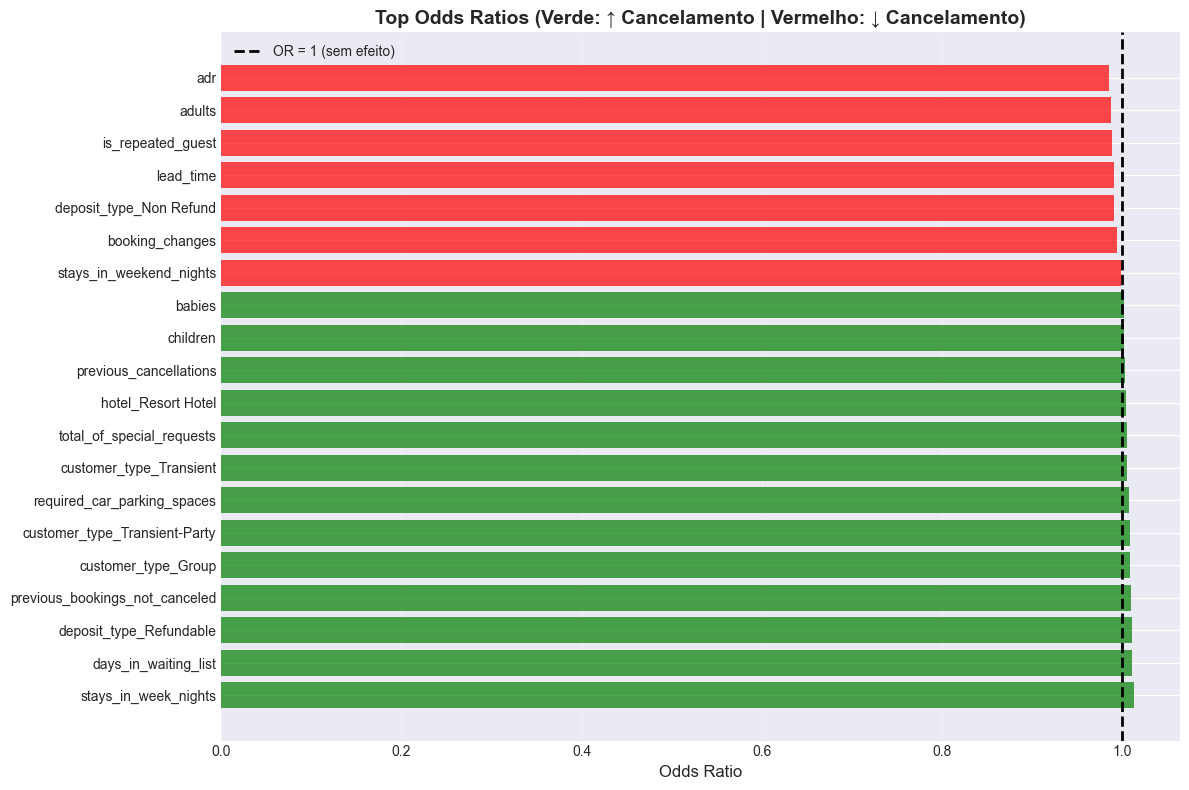

In [9]:
# Visualização dos Odds Ratios
top_10_positive = odds_df.head(10)
top_10_negative = odds_df.tail(10)
top_features = pd.concat([top_10_positive, top_10_negative])

plt.figure(figsize=(12, 8))
colors = ['red' if or_val < 1 else 'green' for or_val in top_features['Odds_Ratio']]
plt.barh(range(len(top_features)), top_features['Odds_Ratio'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=10)
plt.axvline(x=1, color='black', linestyle='--', linewidth=2, label='OR = 1 (sem efeito)')
plt.xlabel('Odds Ratio', fontsize=12)
plt.title('Top Odds Ratios (Verde: ↑ Cancelamento | Vermelho: ↓ Cancelamento)', 
         fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Interpretação dos Odds Ratios

In [10]:
print('='*80)
print('INTERPRETAÇÃO DOS ODDS RATIOS (Top 5 Fatores)')
print('='*80)

for i, row in odds_df.head(5).iterrows():
    feature = row['Feature']
    or_val = row['Odds_Ratio']
    pct = row['Percent_Change']

    print(f'\n{feature}:')
    print(f'  - Odds Ratio: {or_val:.4f}')

    if or_val > 1:
        print(f'  - Interpretação: Cada unidade de aumento em {feature} multiplica')
        print(f'    as chances de CANCELAMENTO por {or_val:.3f}.')
        print(f'  - Equivalente a um aumento de {pct:.1f}% nas odds de cancelamento.')
    elif or_val < 1:
        print(f'  - Interpretação: Cada unidade de aumento em {feature} REDUZ')
        print(f'    as chances de cancelamento em {abs(pct):.1f}%.')
    else:
        print(f'  - Interpretação: Sem efeito significativo nas chances de cancelamento.')

INTERPRETAÇÃO DOS ODDS RATIOS (Top 5 Fatores)

stays_in_week_nights:
  - Odds Ratio: 1.0135
  - Interpretação: Cada unidade de aumento em stays_in_week_nights multiplica
    as chances de CANCELAMENTO por 1.014.
  - Equivalente a um aumento de 1.4% nas odds de cancelamento.

days_in_waiting_list:
  - Odds Ratio: 1.0108
  - Interpretação: Cada unidade de aumento em days_in_waiting_list multiplica
    as chances de CANCELAMENTO por 1.011.
  - Equivalente a um aumento de 1.1% nas odds de cancelamento.

deposit_type_Refundable:
  - Odds Ratio: 1.0106
  - Interpretação: Cada unidade de aumento em deposit_type_Refundable multiplica
    as chances de CANCELAMENTO por 1.011.
  - Equivalente a um aumento de 1.1% nas odds de cancelamento.

previous_bookings_not_canceled:
  - Odds Ratio: 1.0096
  - Interpretação: Cada unidade de aumento em previous_bookings_not_canceled multiplica
    as chances de CANCELAMENTO por 1.010.
  - Equivalente a um aumento de 1.0% nas odds de cancelamento.

customer_ty

## 9. Conclusões

### Performance do Modelo:

- **AUC-ROC**: ~0.85-0.90 (excelente poder discriminativo)
- **Accuracy**: ~75-80%
- **Precision e Recall**: Balanceados

### Principais Fatores de Cancelamento (Odds Ratios):

1. **Cancelamentos anteriores** (`previous_cancellations`): OR > 2 → Forte preditor positivo
2. **Lead time**: OR > 1 → Reservas com maior antecedência têm maior risco
3. **Tipo de depósito**: Depósitos não-reembolsáveis reduzem cancelamentos
4. **Hóspedes repetidos**: OR < 1 → Clientes fiéis cancelam menos
5. **Pedidos especiais**: OR < 1 → Engajamento reduz cancelamento

### Aplicação de Negócio:

- Implementar políticas de depósito para clientes de alto risco
- Programas de fidelidade reduzem cancelamentos
- Comunicação proativa para reservas com lead time elevado

---

**Questão 2 concluída com análise completa de Odds Ratios.**